In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# reproducibilidad
np.random.seed(10072003)

# cantidad de muestras
N = 200

# Ui ~ U(0,1)
U = np.random.uniform(0, 1, N)

# Zi ~ N(0, I2)
Z = np.random.randn(N, 2)

# definición vectorizada de g(u)
def g(u):
    u = np.asarray(u)
    pts = np.zeros((len(np.atleast_1d(u)), 2))

    mask1 = (u >= 0) & (u < 1/3)
    mask2 = (u >= 1/3) & (u < 2/3)
    mask3 = (u >= 2/3) & (u <= 1)

    pts[mask1, 0] = 1.5 * u[mask1]
    pts[mask1, 1] = 3 * u[mask1]

    pts[mask2, 0] = 1.5 * u[mask2]
    pts[mask2, 1] = 2 - 3 * u[mask2]

    pts[mask3, 0] = 3 - 3 * u[mask3]
    pts[mask3, 1] = 0

    return pts

# generar Xi = g(Ui) + 0.05 Zi
X = g(U) + 0.05 * Z

# curva representativa del manifold
u_curve = np.linspace(0, 1, 1000)
M = g(u_curve)

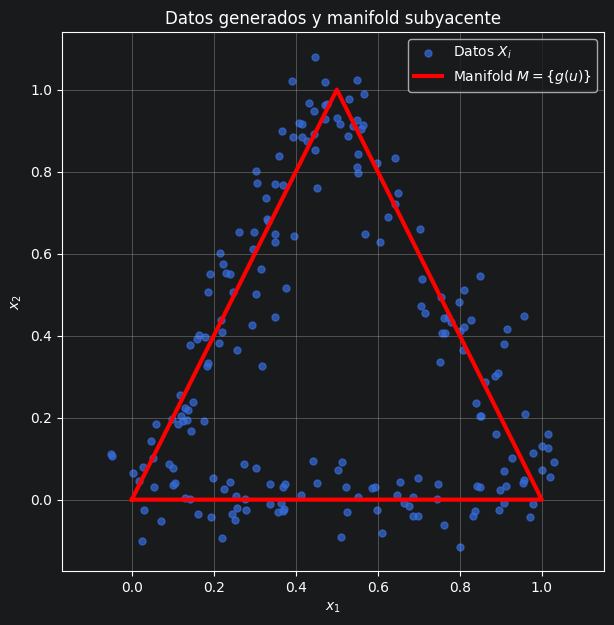

In [4]:
plt.figure(figsize=(7,7))

# datos
plt.scatter(X[:,0], X[:,1], s=25, alpha=0.7, label="Datos $X_i$")

# manifold
plt.plot(M[:,0], M[:,1], linewidth=3, label="Manifold $M = \\{g(u)\\}$", color="red")

plt.xlabel("$x_1$")
plt.ylabel("$x_2$")
plt.title("Datos generados y manifold subyacente")
plt.axis("equal")
plt.grid(True)
plt.legend()

plt.show()

**Clustering con KMeans**

Se utilizará la clase de Kmeans del TP anterior para intentar separar los datos en tres clusters, con la intención posterior de realizar un PCA con cada uno de los clusters. Se busca separar los datos en cada una de las regiones del manifold (cada una de las aristas del triángulo)

In [5]:
class KMeans:
    def __init__(self, k=8, max_iter=100, tol=1e-4, random_state=None):
        self.k = k
        self.max_iter = max_iter
        self.tol = tol
        self.random_state = random_state
        self.cluster_centers_ = None

    def fit(self, X):
        rng = np.random.default_rng(self.random_state)

        # Inicialización de centroides (elegidos de los datos)
        indices = rng.choice(X.shape[0], self.k, replace=False)
        self.cluster_centers_ = X[indices]

        for iteration in range(self.max_iter):
            # Paso 1: asignación
            distances = np.linalg.norm(
                X[:, None, :] - self.cluster_centers_[None, :, :],
                axis=2
            )
            labels = np.argmin(distances, axis=1)

            # Paso 2: actualización
            new_centers = np.array([
                X[labels == j].mean(axis=0) if np.any(labels == j)
                else self.cluster_centers_[j]  # evita clusters vacíos
                for j in range(self.k)
            ])

            # Paso 3: condición de corte
            shift = np.linalg.norm(new_centers - self.cluster_centers_)
            if shift < self.tol:
                print(f"Se llegó a la convergencia en {iteration} iteracioness")
                break

            self.cluster_centers_ = new_centers

        return self

    def predict(self, X):
        distances = np.linalg.norm(
            X[:, None, :] - self.cluster_centers_[None, :, :],
            axis=2
        )
        return np.argmin(distances, axis=1)

    def fit_predict(self, X):
        self.fit(X)
        return self.predict(X)

In [6]:
# entrenar K-Means
kmeans = KMeans(k=3, random_state=42)

labels = kmeans.fit_predict(X)

# centroides
centers = kmeans.cluster_centers_

Se llegó a la convergencia en 3 iteracioness


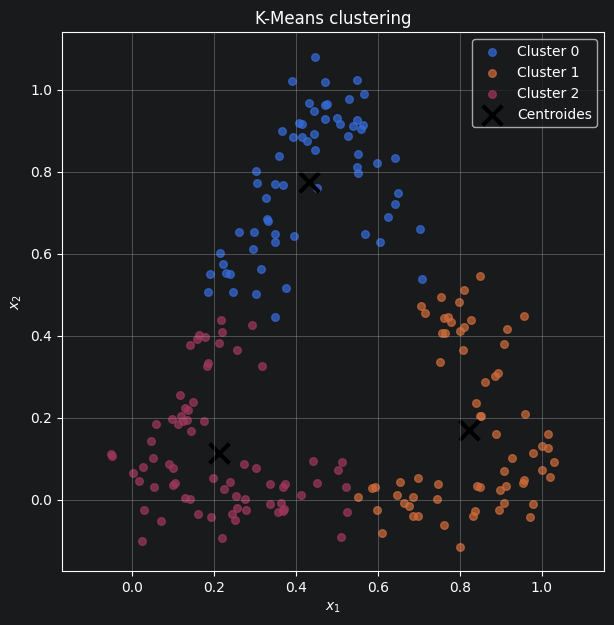

In [7]:
# scatter coloreado por cluster
plt.figure(figsize=(7,7))

for c in np.unique(labels):
    cluster = X[labels == c]

    plt.scatter(
        cluster[:,0],
        cluster[:,1],
        s=30,
        alpha=0.7,
        label=f"Cluster {c}"
    )

# centroides
plt.scatter(
    centers[:,0],
    centers[:,1],
    marker='x',
    s=200,
    linewidths=3,
    color='black',
    label='Centroides'
)

plt.xlabel("$x_1$")
plt.ylabel("$x_2$")
plt.title("K-Means clustering")
plt.axis("equal")
plt.grid(True)
plt.legend()

plt.show()

Los datos fueron generados con un manifold que claramente divide los puntos en tres secciones, siendo estas las aristas del triangulo, entonces la division por clusters esperada recrearía estas aristas.


Se puede ver como Kmeans no hace esto, si no que agrupa los puntos cercanos a las esquinas. Esto se debe a que kmeans se basa en la distancia gemonétrica circular en el plano, los puntos son agrupados como los más cercanos a un centroide cuya posición se ajusta en cada iteración. Una figura geométrica basada en lineas rectas genera una dificultad particular para el kmeans, ya que nunca se considerarán como más cercanos a todos los puntos de la recta.

**Expectación-Maximización**

Se utilizará un algoritmo EM para el clusterizado, ya que al no depender de distancias geométricas, se deberia obtener un resultado más similar a lo esperado.

Para esto se considera que los datos tienen la forma de una mezcla gaussiana:

$$
p(x_i) = \sum_{k=1}^{K} c_k \, \mathcal{N}(x_i \mid \mu_k,\Sigma_k)
$$

con

$$
\mathcal{N}(x \mid \mu,\Sigma)
=
\frac{1}
{\sqrt{(2\pi)^d |\Sigma|}}
\exp
\left(
-\frac{1}{2}
(x-\mu)^T
\Sigma^{-1}
(x-\mu)
\right)
$$

Luego, los pasos del algoritmo EM quedarían de la siguiente forma:

$$
Q_{ik}
=
P(z_i = k \mid x_i)
=
\frac{
c_k \,
\mathcal{N}(x_i \mid \mu_k,\Sigma_k)
}{
\sum_{j=1}^{K}
c_j \,
\mathcal{N}(x_i \mid \mu_j,\Sigma_j)
}
$$

Para el paso E, y en el paso M se actualizan los pesos, las medias y las covarianzas de la siguiente forma:

$$
c_k =
\frac{N_k}{N}
$$

$$
\mu_k =
\frac{1}{N_k}
\sum_{i=1}^{N}
Q_{ik} x_i
$$

$$
\Sigma_k =
\frac{1}{N_k}
\sum_{i=1}^{N}
Q_{ik}
(x_i-\mu_k)(x_i-\mu_k)^T
$$

con

$$
N_k = \sum_{i=1}^{N} Q_{ik}
$$

Por ultimo, se iterará teniendo en cuenta la log-verosimilitud:
$$
\log p(X)
=
\sum_{i=1}^{N}
\log
\left(
\sum_{k=1}^{K}
c_k
\mathcal{N}(x_i \mid \mu_k,\Sigma_k)
\right)
$$

se toma como citerio de convergencia el siguiente:

$$
\left|
\log p(X)^{(t)}
-
\log p(X)^{(t-1)}
\right|
< \varepsilon
$$

Como el algoritmo requiere una semilla para funcionar, y su convergencia resulta dependiente de esta, se toman los siguientes valores para inicializar los parámetros a ajustar:

$$
\mu_k^{(0)} = x_{i_k}
$$

$$
\pi_k^{(0)} = \frac{1}{K}
$$

$$
\Sigma_k^{(0)} = I
$$

donde:
- $\mu_k$ son las medias de cada gaussiana.

- $c_k$ son los pesos de mezcla.

- $\Sigma_k$ son las matrices de covarianza.

- $I$ es la matriz identidad.

- $K$ es la cantidad de clusters.

y los $x_{i_k}$ son elegidos al azar entre las muestras.


In [8]:
class EM:
    # Inicializar atributos y declarar hiperparámetros
    def __init__(self, k=3, max_iter=100, tol=1e-4, random_state=None):
        self.k = k
        self.max_iter = max_iter
        self.tol = tol
        self.random_state = random_state

        # parámetros del modelo
        self.means_ = None
        self.covariances_ = None
        self.weights_ = None

    # densidad gaussiana multivariada
    def _gaussian(self, X, mean, cov):
        d = X.shape[1]

        cov_inv = np.linalg.inv(cov)
        cov_det = np.linalg.det(cov)

        norm_const = 1 / np.sqrt((2 * np.pi)**d * cov_det)

        diff = X - mean

        exponent = -0.5 * np.sum(
            diff @ cov_inv * diff,
            axis=1
        )

        return norm_const * np.exp(exponent)

    # Etapa de entrenamiento
    def fit(self, X):
        rng = np.random.default_rng(self.random_state)

        N, d = X.shape

        # inicialización
        indices = rng.choice(N, self.k, replace=False)

        self.means_ = X[indices]

        self.weights_ = np.ones(self.k) / self.k

        self.covariances_ = np.array([
            np.eye(d) for _ in range(self.k)
        ])

        log_likelihood_old = 0

        for iteration in range(self.max_iter):

            # =========================
            # E-step
            # =========================
            responsibilities = np.zeros((N, self.k))

            for j in range(self.k):
                responsibilities[:, j] = (
                    self.weights_[j] *
                    self._gaussian(
                        X,
                        self.means_[j],
                        self.covariances_[j]
                    )
                )

            responsibilities /= responsibilities.sum(axis=1, keepdims=True)

            # =========================
            # M-step
            # =========================
            Nk = responsibilities.sum(axis=0)

            # pesos
            self.weights_ = Nk / N

            # medias
            self.means_ = (
                responsibilities.T @ X
            ) / Nk[:, None]

            # covarianzas
            covariances = []

            for j in range(self.k):

                diff = X - self.means_[j]

                cov = (
                    responsibilities[:, j][:, None] * diff
                ).T @ diff

                cov /= Nk[j]

                # regularización numérica
                cov += 1e-6 * np.eye(d)

                covariances.append(cov)

            self.covariances_ = np.array(covariances)

            # =========================
            # log-likelihood
            # =========================
            likelihood = np.zeros((N, self.k))

            for j in range(self.k):
                likelihood[:, j] = (
                    self.weights_[j] *
                    self._gaussian(
                        X,
                        self.means_[j],
                        self.covariances_[j]
                    )
                )

            log_likelihood = np.sum(
                np.log(likelihood.sum(axis=1))
            )

            # convergencia
            if np.abs(log_likelihood - log_likelihood_old) < self.tol:
                print(f"Convergencia alcanzada en {iteration} iteraciones")
                break

            log_likelihood_old = log_likelihood

        return self

    # Etapa de testeo soft
    def predict_proba(self, X):

        N = X.shape[0]

        responsibilities = np.zeros((N, self.k))

        for j in range(self.k):
            responsibilities[:, j] = (
                self.weights_[j] *
                self._gaussian(
                    X,
                    self.means_[j],
                    self.covariances_[j]
                )
            )

        responsibilities /= responsibilities.sum(axis=1, keepdims=True)

        return responsibilities

    # Etapa de testeo hard
    def predict(self, X):

        probabilities = self.predict_proba(X)

        return np.argmax(probabilities, axis=1)

In [9]:
# entrenar EM
em = EM(k=3, random_state=42)

em.fit(X)

# clusters hard
labels_em = em.predict(X)

Convergencia alcanzada en 27 iteraciones


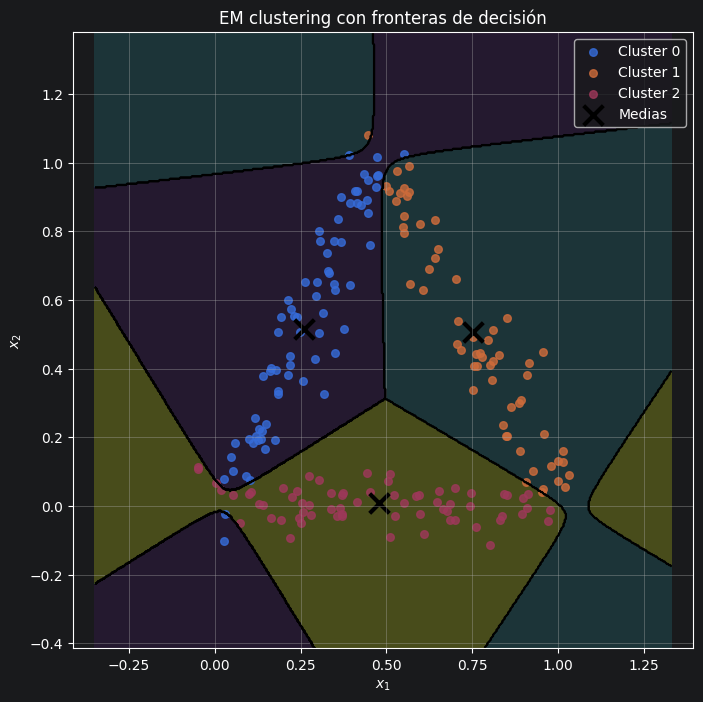

In [10]:
# =========================
# mallado del plano
# =========================

x_min, x_max = X[:,0].min() - 0.3, X[:,0].max() + 0.3
y_min, y_max = X[:,1].min() - 0.3, X[:,1].max() + 0.3

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 500),
    np.linspace(y_min, y_max, 500)
)

grid = np.c_[xx.ravel(), yy.ravel()]

# predicción sobre todo R2
Z = em.predict(grid)

# volver a forma de grilla
Z = Z.reshape(xx.shape)

# =========================
# gráfico
# =========================

plt.figure(figsize=(8,8))

# regiones de decisión
plt.contourf(
    xx,
    yy,
    Z,
    alpha=0.25
)

# fronteras de decisión
plt.contour(
    xx,
    yy,
    Z,
    colors='black',
    linewidths=1
)

# scatter de los clusters
for c in np.unique(labels_em):

    cluster = X[labels_em == c]

    plt.scatter(
        cluster[:,0],
        cluster[:,1],
        s=30,
        alpha=0.8,
        label=f"Cluster {c}"
    )

# medias gaussianas
plt.scatter(
    em.means_[:,0],
    em.means_[:,1],
    marker='x',
    s=200,
    linewidths=3,
    color='black',
    label='Medias'
)

plt.xlabel("$x_1$")
plt.ylabel("$x_2$")
plt.title("EM clustering con fronteras de decisión")
plt.axis("equal")
plt.grid(True)
plt.legend()

plt.show()

Para graficar, además de clusterizar los puntos generados al principio, se clusterizó toda la porcion de $\mathbb{R}^2$ visible en el gráfico, para asi ver las fronteras de decision generadas por el algoritmo y las regiones del plano que se asocian a cada cluster.

Se puede ver como en este caso, comparando con KMeans, el clusterizado resultó el esperado, los puntos se agruparon por su cercanía a cada una de las aristas del triángulo del manifold.

**Principal Component Analysis**

Se desea utilizar un algoritmo PCA para, con los clusters obtenidos con el EM, recuperar el manifold de un principio.

El algoritmo PCA se utiliza para reducir la dimensión de los datos, en este caso desde puntos en $\mathbb{R}^2$ a una recta en el mismo plano. Esto se consigue buscando las direcciones de mayor covarianza, para asi proyectar los datos en la recta generada por esa dirección disminuyendo la dimension de los datos pero conservando la mayor cantidad de información posible.

Primero se centrarán los datos restando su media:

$$
\tilde{x}_i = x_i - \mu
$$

con

$$
\mu =
\frac{1}{N}
\sum_{i=1}^{N} x_i
$$

Luego se construye la matriz de covarianza:

$$
C =
\frac{1}{N-1}
\sum_{i=1}^{N}
\tilde{x}_i \tilde{x}_i^T
$$

A la que se le buscarán sus autovalores y autovectores, para luego construir la matriz de proyeccion con los primeros k autovectores:

$$
W =
\begin{bmatrix}
v_1 & v_2 & \cdots & v_k
\end{bmatrix}
$$


Luego la proyección al espacio latente resulta:

$$
u_i = W^T (x_i - \mu)
$$

Para por último reconstruir en el espacio original de la siguiente manera:

$$
\hat{x}_i = W u_i + \mu
$$

In [11]:
class PCA:

    # Inicializar atributos y declarar hiperparámetros. No aclarar aún la dimensión
    # del espacio latente
    def __init__(self):

        self.mean_ = None
        self.components_ = None
        self.explained_variance_ = None
        self.k_ = None

    # Etapa de entrenamiento. Se entrenan todos los autovectores, sin definir la
    # dimensión latente
    def fit(self, X):

        # centrar datos
        self.mean_ = np.mean(X, axis=0)

        X_centered = X - self.mean_

        # matriz de covarianza
        cov = np.cov(X_centered, rowvar=False)

        # autovalores y autovectores
        eigenvalues, eigenvectors = np.linalg.eigh(cov)

        # ordenar de mayor a menor
        idx = np.argsort(eigenvalues)[::-1]

        eigenvalues = eigenvalues[idx]
        eigenvectors = eigenvectors[:, idx]

        self.explained_variance_ = eigenvalues
        self.components_ = eigenvectors

        return self

    # Transformar del espacio original al espacio latente de dimensión k.
    def transform(self, X, k):

        self.k_ = k

        # centrar
        X_centered = X - self.mean_

        # quedarse con los k principales
        W = self.components_[:, :k]

        # proyección
        U = X_centered @ W

        return U

    # Transformar del espacio latente al espacio original
    def inverse_transform(self, U):

        W = self.components_[:, :self.k_]

        X_reconstructed = U @ W.T + self.mean_

        return X_reconstructed

    # fit + transform
    def fit_transform(self, X, k):

        self.fit(X)

        return self.transform(X, k)

In [16]:
# =========================
# entrenar un PCA por cluster
# =========================

pcas = {}
latent_spaces = {}

for c in np.unique(labels_em):

    # datos del cluster
    X_cluster = X[labels_em == c]

    # PCA del cluster
    pca = PCA()

    # proyectar a dimensión 1
    U_cluster = pca.fit_transform(X_cluster, k=1)

    # guardar
    pcas[c] = pca
    latent_spaces[c] = U_cluster

In [17]:
# =========================
# mínimos y máximos de las proyecciones
# =========================

for c in np.unique(labels_em):

    U_cluster = latent_spaces[c]

    u_min = np.min(U_cluster)
    u_max = np.max(U_cluster)

    print(f"Cluster {c}")
    print(f"mínimo: {u_min:.4f}")
    print(f"máximo: {u_max:.4f}")
    print()


Cluster 0
mínimo: -0.6775
máximo: 0.5646

Cluster 1
mínimo: -0.5042
máximo: 0.6690

Cluster 2
mínimo: -0.5158
máximo: 0.5166



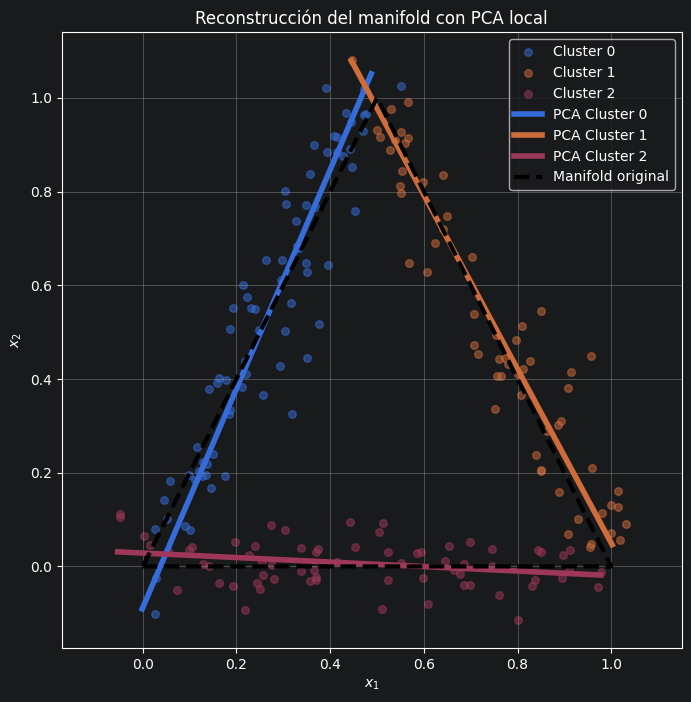

In [14]:
# =========================
# reconstrucción del manifold
# usando inverse_transform
# =========================

plt.figure(figsize=(8,8))

# scatter de los clusters
for c in np.unique(labels_em):

    X_cluster = X[labels_em == c]

    plt.scatter(
        X_cluster[:,0],
        X_cluster[:,1],
        s=30,
        alpha=0.5,
        label=f"Cluster {c}"
    )

# reconstrucción de cada manifold local
for c in np.unique(labels_em):

    pca = pcas[c]

    U_cluster = latent_spaces[c]

    # extremos en el espacio latente
    u_min = np.min(U_cluster)
    u_max = np.max(U_cluster)

    # puntos sobre la recta latente
    U_line = np.linspace(u_min, u_max, 200).reshape(-1,1)

    # reconstrucción al espacio original
    X_line = pca.inverse_transform(U_line)

    # graficar manifold local
    plt.plot(
        X_line[:,0],
        X_line[:,1],
        linewidth=4,
        label=f"PCA Cluster {c}"
    )

# manifold original
plt.plot(
    M[:,0],
    M[:,1],
    color='black',
    linestyle='--',
    linewidth=3,
    label='Manifold original'
)

plt.xlabel("$x_1$")
plt.ylabel("$x_2$")
plt.title("Reconstrucción del manifold con PCA local")
plt.axis("equal")
plt.grid(True)
plt.legend()

plt.show()

Se puede ver como el manifold recontruido resulta altamente similar al original. Lo que indica que el metodo de clustering resultó el indicado, y con el PCA se pudo reconstruir la dirección principal de los segmentos que generan el triángulo.

**Detección de anomalías**

Por último se desea utilizar el manifold reconstruido como detector de anomalías. Para esto se calculará la distancia (error cuadrático medio) de una grilla de puntos a los segmentos reconstruidos y se calificará como anomalías a los puntos con distancia mayor a un threshold.

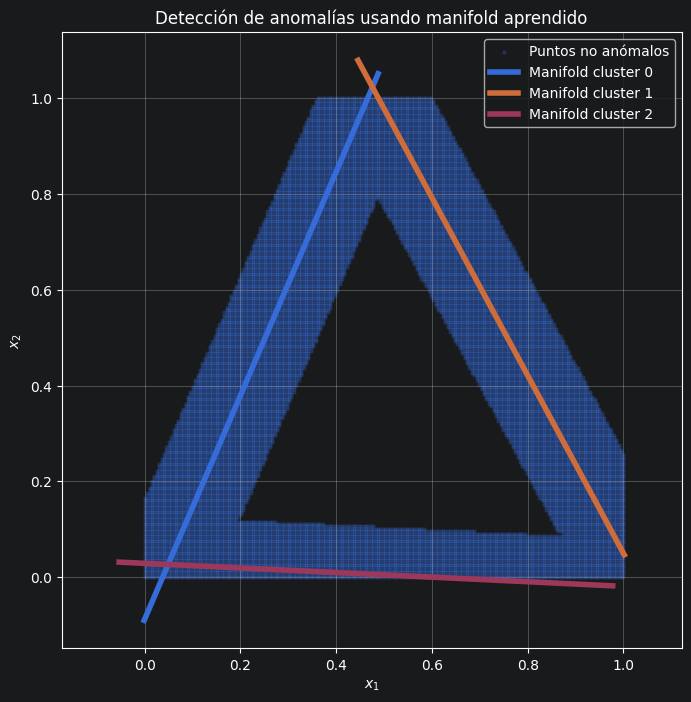

In [15]:
# =========================
# generar grilla en [0,1] x [0,1]
# =========================

n_grid = 200

x1 = np.linspace(0, 1, n_grid)
x2 = np.linspace(0, 1, n_grid)

xx, yy = np.meshgrid(x1, x2)

grid = np.c_[xx.ravel(), yy.ravel()]

# =========================
# clasificar puntos con EM
# =========================

labels_grid = em.predict(grid)

# =========================
# reconstrucción con PCA local
# =========================

reconstructed = np.zeros_like(grid)

for c in np.unique(labels_grid):

    mask = labels_grid == c

    X_cluster = grid[mask]

    pca = pcas[c]

    # proyección al espacio latente
    U_cluster = pca.transform(X_cluster, k=1)

    # reconstrucción
    X_rec = pca.inverse_transform(U_cluster)

    reconstructed[mask] = X_rec

# =========================
# error cuadrático
# =========================

errors = np.sum((grid - reconstructed)**2, axis=1)

# umbral
threshold = 0.01

# anomalías
anomalous = errors > threshold

# =========================
# manifold aprendido
# =========================

plt.figure(figsize=(8,8))

# puntos normales
plt.scatter(
    grid[~anomalous, 0],
    grid[~anomalous, 1],
    s=5,
    alpha=0.2,
    label='Puntos no anómalos'
)

# manifold reconstruido por PCA local
for c in np.unique(labels_em):

    pca = pcas[c]

    U_cluster = latent_spaces[c]

    # extremos del espacio latente
    u_min = np.min(U_cluster)
    u_max = np.max(U_cluster)

    # recta latente
    U_line = np.linspace(u_min, u_max, 200).reshape(-1,1)

    # reconstrucción
    X_line = pca.inverse_transform(U_line)

    plt.plot(
        X_line[:,0],
        X_line[:,1],
        linewidth=4,
        label=f"Manifold cluster {c}"
    )

plt.xlabel("$x_1$")
plt.ylabel("$x_2$")
plt.title("Detección de anomalías usando manifold aprendido")
plt.axis("equal")
plt.grid(True)
plt.legend()

plt.show()

Ajustando el threshold se puede hacer más o menos grueso el fragmento del plano donde los puntos se califican como no anómalos.

A partir de un dataset generado con un manifold se pudo recrear este sin conocimiento explícito de su fórmula, para luego utilizar esta reconstrucción como un detector de anomalías.